In [17]:
from sklearn.datasets import load_iris
import pandas as pd

In [18]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [19]:
#Understanding the data
df.shape


(150, 5)

In [20]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [22]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [23]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [24]:
X = df.drop("target",axis=1)

In [26]:
X.shape

(150, 4)

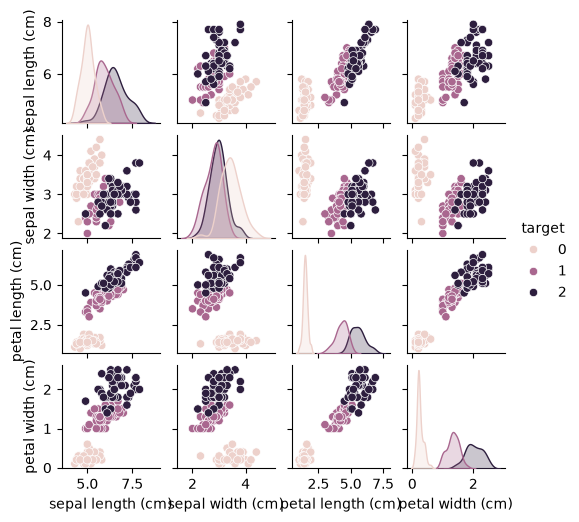

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="target",height=1.3)
plt.show()

In [30]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])
print(X_scaled.shape)

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]
(150, 4)


In [34]:
from sklearn.cluster import KMeans

inertia= []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        init = "k-means++",
        n_init = 10,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

In [35]:
print(inertia)

[600.0000000000001, 222.36170496502308, 139.82049635974982, 114.09254690403091, 90.92751382392052, 81.54439095511782, 72.63114382667189, 62.54060569578123, 55.119492805290605, 47.3910351763471]


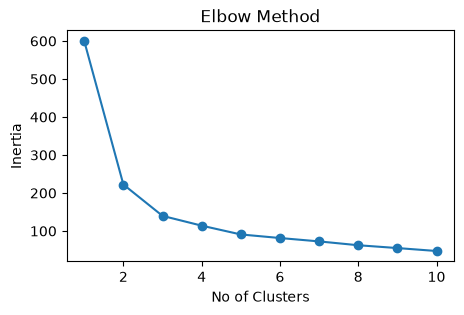

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

plt.plot(range(1,11),inertia,marker='o')

plt.xlabel("No of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


In [38]:
from sklearn.metrics import silhouette_score

silhouette_scores=[]

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    label = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,label)

    silhouette_scores.append(score)

print(silhouette_scores)    

[0.5817500491982808, 0.45994823920518635, 0.38694104154427816, 0.3459012795948778, 0.31707940193569023, 0.3201967939183684, 0.33869173894897225, 0.3423598384813203, 0.3517926760640288]


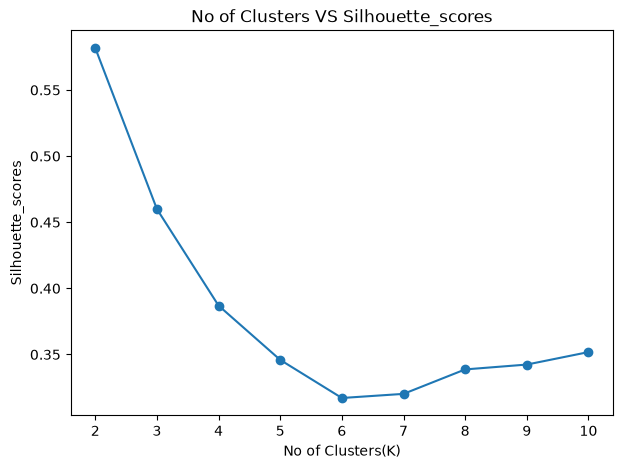

In [39]:
plt.figure(figsize=(7,5))

plt.plot(range(2,11),silhouette_scores,marker='o')

plt.xlabel("No of Clusters(K)")
plt.ylabel("Silhouette_scores")
plt.title("No of Clusters VS Silhouette_scores")

plt.show()